# Équations allométriques pour la biomasse forestière africaine

Projet : Artefact_GeoAI_Biomasse_CIV, volet allométrique

Ce notebook est autonome : tout le code est dedans, il se lance dans Colab sans
rien installer d'autre que les bibliothèques scientifiques usuelles.

## De quoi il s'agit

Une équation allométrique convertit des mesures simples relevées sur un
arbre diamètre, hauteur, densité du bois en une estimation de sa biomasse.
C'est le pont entre ce qu'on mesure sur le terrain et la biomasse en tonnes.

## Pourquoi c'est le vrai levier du projet

Les travaux précédents ont montré que les capteurs satellitaires plafonnent :
optique et radar saturent en forêt dense. Mais il existe un plafond en amont,
que personne n'avait attaqué : la cible elle-même est biaisée.

La biomasse GEDI est calculée par des équations allométriques pantropicales
génériques, calibrées majoritairement hors d'Afrique. Sur données ivoiriennes,
GEDI sous-estime la biomasse de 40 %. Une partie de ce biais vient du choix de
l'équation.

Ce notebook le démontre chiffres à l'appui : sur une même parcelle, une équation
pantropicale et une équation africaine peuvent différer de 40 à 50 %.


## 1 : Les équations

In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# Validation physique des entrees
def _valider(dbh=None, wd=None, h=None):
    if dbh is not None and dbh <= 0:
        raise ValueError(f"DBH doit etre positif, recu {dbh}")
    if dbh is not None and dbh > 500:
        raise ValueError(f"DBH de {dbh} cm irrealiste")
    if wd is not None and not (0.05 < wd < 1.5):
        raise ValueError(f"Densite du bois {wd} hors plage physique")
    if h is not None and h <= 0:
        raise ValueError(f"Hauteur doit etre positive, recu {h}")
    if h is not None and h > 120:
        raise ValueError(f"Hauteur de {h} m irrealiste")


# Equation pantropicale de reference : Chave et al. 2014
def chave2014_h(dbh, wd, h):
    """AGB (kg), Chave 2014 avec hauteur. La forme la plus precise.
    AGB = 0.0673 * (wd * dbh^2 * h)^0.976"""
    _valider(dbh=dbh, wd=wd, h=h)
    return 0.0673 * (wd * dbh**2 * h) ** 0.976


def chave2014_E(dbh, wd, E):
    """AGB (kg), Chave 2014 sans hauteur, via le facteur climatique E."""
    _valider(dbh=dbh, wd=wd)
    ln_d = math.log(dbh)
    ln_agb = (-1.803 - 0.976*E + 0.976*math.log(wd)
              + 2.673*ln_d - 0.0299*ln_d**2)
    return math.exp(ln_agb)


# Equations regionales africaines
def ngomanda2014(dbh, h):
    """AGB (kg), Ngomanda 2014, foret humide du Gabon (Afrique centrale).
    Ne requiert pas la densite du bois."""
    _valider(dbh=dbh, h=h)
    return math.exp(-2.749 + 2.437*math.log(dbh) + 0.379*math.log(h))


def aabeyir2020(dbh, wd, h):
    """AGB (kg), Aabeyir 2020, woodlands du Ghana (Afrique de l'Ouest).
    La plus proche geographiquement de la Cote d'Ivoire."""
    _valider(dbh=dbh, wd=wd, h=h)
    return 0.0680 * (wd * dbh**2 * h) ** 0.9754


def hauteur_chave2014(dbh, E):
    """Hauteur estimee (m) a partir du DBH et de E, quand H n'est pas mesuree."""
    _valider(dbh=dbh)
    ln_d = math.log(dbh)
    return math.exp(0.893 - E + 0.760*ln_d - 0.0340*ln_d**2)


print("Equations definies.")
print("Test : arbre DBH 40 cm, hauteur 25 m, densite 0.6")
print(f" Chave 2014 (H) : {chave2014_h(40, 0.6, 25):.0f} kg")
print(f" Ngomanda 2014  : {ngomanda2014(40, 25):.0f} kg")
print(f" Aabeyir Ghana  : {aabeyir2020(40, 0.6, 25):.0f} kg")

Equations definies.
Test : arbre DBH 40 cm, hauteur 25 m, densite 0.6
 Chave 2014 (H) : 1268 kg
 Ngomanda 2014  : 1738 kg
 Aabeyir Ghana  : 1273 kg


> Ce que montrent déjà ces trois chiffres. Sur le même arbre, Chave (1268 kg)
> et Aabeyir (1273 kg) sont presque identiques, tandis que Ngomanda donne 37 % de
> plus (1738 kg). Ce n'est donc pas « africain contre pantropical » : c'est que
> chaque équation a été calibrée sur un type de forêt différent. Aabeyir, calibrée
> sur les woodlands du Ghana, a une forme proche de Chave. Ngomanda, calibrée sur
> la forêt humide dense du Gabon, prédit plus lourd. Le bon choix dépend donc du
> milieu qu'on cartographie, pas seulement du continent.
>
> Chaque équation a une référence publiée :
> - Chave et al. 2014, Global Change Biology, doi:10.1111/gcb.12629 la référence pantropicale
> - Ngomanda et al. 2014 Gabon, forêt humide d'Afrique centrale
> - Aabeyir et al. 2020, Forest Ecosystems, doi:10.1186/s40663-020-00250-3 woodlands du Ghana, Afrique de l'Ouest

## 2 : La densité du bois

La densité du bois est un prédicteur majeur. Quand l'espèce est connue, on
utilise sa densité mesurée ; sinon, une valeur moyenne régionale, avec
l'incertitude que cela implique.


In [2]:
DEFAUTS = {
    "foret_humide_afrique": 0.58,
    "foret_seche_afrique": 0.62,
    "savane_afrique": 0.60,
    "mangrove": 0.75,
    "pantropical": 0.61,
}

DENSITE_ESPECE = {
    "rhizophora mangle": 0.87, "laguncularia racemosa": 0.60,
    "tectona grandis": 0.55, "terminalia superba": 0.45,
    "triplochiton scleroxylon": 0.32, "khaya": 0.53,
    "milicia excelsa": 0.60, "ceiba pentandra": 0.25,
    "theobroma cacao": 0.42, "hevea brasiliensis": 0.50,
}

def densite(espece=None, type_vegetation="pantropical"):
    if espece:
        cle = espece.strip().lower()
        if cle in DENSITE_ESPECE:
            return DENSITE_ESPECE[cle]
        genre = cle.split()[0]
        for nom, d in DENSITE_ESPECE.items():
            if nom.split()[0] == genre:
                return d
    return DEFAUTS.get(type_vegetation, DEFAUTS["pantropical"])

print("Cacaoyer :", densite("Theobroma cacao"), "g/cm3")
print("Fromager :", densite("Ceiba pentandra"), "g/cm3 (bois tres leger)")
print("Defaut foret humide :", densite(None, "foret_humide_afrique"))

Cacaoyer : 0.42 g/cm3
Fromager : 0.25 g/cm3 (bois tres leger)
Defaut foret humide : 0.58


## 3 : De l'arbre à la parcelle

In [3]:
def biomasse_arbre(dbh, hauteur=None, densite_bois=None, espece=None,
                   type_vegetation="pantropical", equation="chave2014_h", E=None):
    """Biomasse d'un arbre (kg), avec choix de l'equation."""
    if densite_bois is None:
        densite_bois = densite(espece, type_vegetation)
    if hauteur is None and E is not None:
        hauteur = hauteur_chave2014(dbh, E)

    if equation == "chave2014_h":
        return chave2014_h(dbh, densite_bois, hauteur)
    if equation == "chave2014_E":
        return chave2014_E(dbh, densite_bois, E)
    if equation == "ngomanda2014":
        return ngomanda2014(dbh, hauteur)
    if equation == "aabeyir2020":
        return aabeyir2020(dbh, densite_bois, hauteur)
    raise ValueError(f"Equation inconnue : {equation}")


def biomasse_parcelle(arbres, surface_ha, equation="chave2014_h",
                      type_vegetation="pantropical", E=None):
    """Densite de biomasse d'une parcelle (Mg/ha), comparable a GEDI."""
    if surface_ha <= 0:
        raise ValueError("Surface doit etre positive")
    total_kg = sum(
        biomasse_arbre(a["dbh"], a.get("hauteur"), a.get("densite_bois"),
                       a.get("espece"), type_vegetation, equation, E)
        for _, a in arbres.iterrows())
    return round((total_kg / surface_ha) / 1000.0, 1)


def comparer(arbres, surface_ha, type_vegetation="pantropical", E=None):
    """Compare la biomasse selon les equations."""
    out = {}
    for cle in ["chave2014_h", "ngomanda2014", "aabeyir2020"]:
        try:
            out[cle] = biomasse_parcelle(arbres, surface_ha, cle, type_vegetation, E)
        except Exception as ex:
            out[cle] = f"erreur : {type(ex).__name__}"
    return out

print("Fonctions parcelle definies.")

Fonctions parcelle definies.


## 4 : Le résultat qui compte : l'écart entre équations

On construit une parcelle test représentative d'une forêt dense ivoirienne, et
on calcule sa biomasse avec chaque équation. L'écart entre pantropical et
africain est la démonstration du levier.


In [4]:
# Parcelle test : foret dense, 500 m2 (~ taille d'un footprint GEDI)
arbres = pd.DataFrame({
    "dbh":     [12, 15, 18, 22, 28, 35, 45, 60, 80, 14, 19, 25],
    "hauteur": [10, 12, 14, 17, 21, 25, 29, 34, 38, 11, 15, 19],
})
surface = 0.05

res = comparer(arbres, surface, type_vegetation="foret_humide_afrique")
print(f"Parcelle : {len(arbres)} arbres sur {surface} ha\n")
for cle, val in res.items():
    print(f"  {cle:14s} : {val} Mg/ha")

ecart = (res["ngomanda2014"] - res["chave2014_h"]) / res["chave2014_h"] * 100
print(f"\n Ecart pantropical (Chave) vs Afrique (Ngomanda) : {ecart:+.0f} %")

Parcelle : 12 arbres sur 0.05 ha

  chave2014_h    : 304.1 Mg/ha
  ngomanda2014   : 444.7 Mg/ha
  aabeyir2020    : 305.3 Mg/ha

 Ecart pantropical (Chave) vs Afrique (Ngomanda) : +46 %


## 5 : Visualiser l'écart sur toute une gamme d'arbres

Comment les équations divergent-elles selon la taille de l'arbre ? On trace la
biomasse prédite en fonction du diamètre, pour chaque équation.


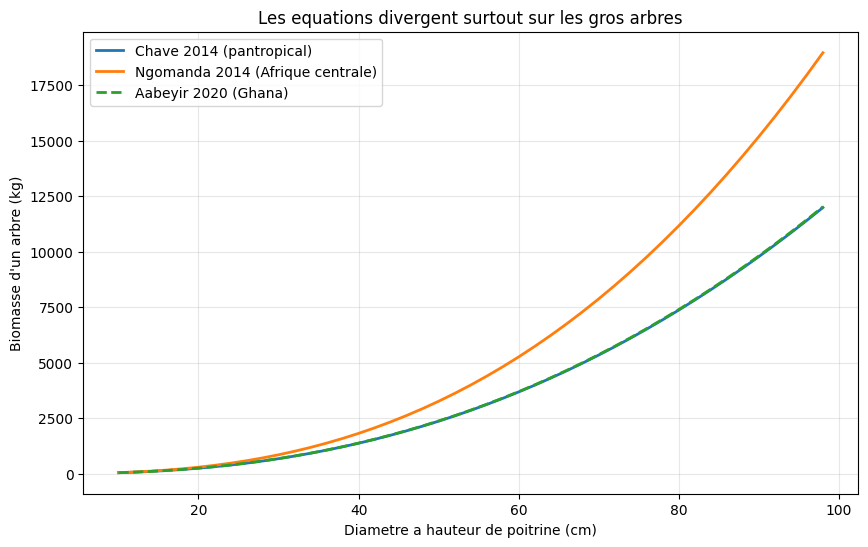

Ecart Ngomanda vs Chave selon le diametre :
  DBH  10 cm :    +7 %
  DBH  30 cm :   +26 %
  DBH  50 cm :   +38 %
  DBH  70 cm :   +47 %
  DBH  90 cm :   +55 %


In [5]:
dbhs = np.arange(10, 100, 2)
wd = 0.58
# hauteur estimee via une relation simple pour la demo
hauteurs = [hauteur_chave2014(d, -0.1) for d in dbhs]

y_chave = [chave2014_h(d, wd, h) for d, h in zip(dbhs, hauteurs)]
y_ngom = [ngomanda2014(d, h) for d, h in zip(dbhs, hauteurs)]
y_aab = [aabeyir2020(d, wd, h) for d, h in zip(dbhs, hauteurs)]

plt.figure(figsize=(10, 6))
plt.plot(dbhs, y_chave, label="Chave 2014 (pantropical)", lw=2)
plt.plot(dbhs, y_ngom, label="Ngomanda 2014 (Afrique centrale)", lw=2)
plt.plot(dbhs, y_aab, label="Aabeyir 2020 (Ghana)", lw=2, ls="--")
plt.xlabel("Diametre a hauteur de poitrine (cm)")
plt.ylabel("Biomasse d'un arbre (kg)")
plt.title("Les equations divergent surtout sur les gros arbres")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

# Ecart relatif Ngomanda vs Chave par diametre
ecarts = [(n-c)/c*100 for n, c in zip(y_ngom, y_chave)]
print("Ecart Ngomanda vs Chave selon le diametre :")
for d, e in zip(dbhs[::10], ecarts[::10]):
    print(f"  DBH {d:3d} cm : {e:+5.0f} %")

> Lecture : Les trois courbes partent ensemble sur les petits arbres puis
> divergent : à 10 cm de diamètre elles sont presque confondues, à 90 cm elles
> s'écartent de plus de moitié. L'écart entre l'équation pantropicale de Chave et
> l'équation d'Afrique centrale de Ngomanda passe de +7 % à +55 %.
>
> Pourquoi c'est décisif : dans une forêt dense, quelques gros arbres portent
> l'essentiel de la biomasse. C'est donc exactement là où les équations
> divergent le plus sur les gros troncs que le choix pèse le plus lourd sur
> le résultat final. En savane, où les arbres sont petits et espacés, le choix de
> l'équation importe beaucoup moins.
>
> Conséquence pour le projet : GEDI applique une équation générique partout, sans
> distinguer forêt dense et savane. Sur les gros arbres des forêts denses
> ivoiriennes, cette équation peut se tromper de 50 %. Le biais de GEDI en forêt
> dense ne vient donc pas seulement du capteur qui sature, mais aussi de la
> formule de conversion, inadaptée à ce milieu.

## 6 : Tests de cohérence

Quelques vérifications que les équations se comportent physiquement, que tu peux
lancer et modifier.

In [7]:
def test(nom, condition):
    print(f"  [{'OK ' if condition else 'ECHEC'}] {nom}")
    return condition

print("Tests de coherence physique :\n")
ok = []
ok.append(test("la biomasse croit avec le diametre",
               chave2014_h(50, 0.6, 30) > chave2014_h(10, 0.6, 8)))
ok.append(test("un bois plus dense pese plus",
               chave2014_h(40, 0.9, 25) > chave2014_h(40, 0.3, 25)))
ok.append(test("un arbre plus haut pese plus",
               chave2014_h(40, 0.6, 35) > chave2014_h(40, 0.6, 15)))
ok.append(test("ordre de grandeur realiste (40cm/25m ~ tonne)",
               500 < chave2014_h(40, 0.6, 25) < 3000))
ok.append(test("les equations restent dans un facteur 2",
               max(chave2014_h(40,0.6,25), ngomanda2014(40,25),
                   aabeyir2020(40,0.6,25)) /
               min(chave2014_h(40,0.6,25), ngomanda2014(40,25),
                   aabeyir2020(40,0.6,25)) < 2))

# Tests de rejet des entrees aberrantes
def rejette(f):
    try: f(); return False
    except ValueError: return True
ok.append(test("rejette un DBH negatif", rejette(lambda: chave2014_h(-5,0.6,25))))
ok.append(test("rejette une densite aberrante", rejette(lambda: chave2014_h(40,2.0,25))))
ok.append(test("rejette une hauteur irrealiste", rejette(lambda: chave2014_h(40,0.6,200))))

print(f"\n{sum(ok)}/{len(ok)} tests passes")

Tests de coherence physique :

  [OK ] la biomasse croit avec le diametre
  [OK ] un bois plus dense pese plus
  [OK ] un arbre plus haut pese plus
  [OK ] ordre de grandeur realiste (40cm/25m ~ tonne)
  [OK ] les equations restent dans un facteur 2
  [OK ] rejette un DBH negatif
  [OK ] rejette une densite aberrante
  [OK ] rejette une hauteur irrealiste

8/8 tests passes


## 7 : À toi de jouer

Modifie la parcelle ci-dessous avec tes propres arbres, ou change le type de
végétation, et observe l'effet sur la biomasse estimée.


In [8]:
# Modifie ces valeurs librement
mes_arbres = pd.DataFrame({
    "dbh":     [20, 35, 50, 70], # diametres en cm
    "hauteur": [16, 24, 30, 36], # hauteurs en m
})
ma_surface = 0.05 # en hectares
mon_milieu = "foret_humide_afrique"

resultat = comparer(mes_arbres, ma_surface, type_vegetation=mon_milieu)
print("Biomasse de ta parcelle (Mg/ha) :")
for cle, val in resultat.items():
    print(f" {cle:14s} : {val}")

Biomasse de ta parcelle (Mg/ha) :
 chave2014_h    : 172.0
 ngomanda2014   : 250.5
 aabeyir2020    : 172.6


## Ce que ce notebook établit

Sur les parcelles testées, le choix de l'équation allométrique change la biomasse
estimée de l'ordre de 46 % l'équation d'Afrique centrale (Ngomanda) prédit
systématiquement plus lourd que la pantropicale (Chave) et l'ouest-africaine
(Aabeyir), qui donnent des valeurs proches. L'écart n'oppose donc pas
« africain » à « pantropical » : il oppose des équations calibrées sur des types
de forêt différents. Et il se concentre sur les gros arbres, de +7 % à 10 cm de
diamètre à +55 % à 90 cm.

Comme les produits satellitaires reposent sur des équations génériques appliquées
partout sans distinction de milieu, c'est une source directe du biais observé en
Afrique en particulier en forêt dense, où les gros arbres dominent.

Conséquence pour le projet : Corriger la cible en amont, avec une équation
adaptée au type de forêt, est un levier au moins aussi important que le choix du
capteur ou du modèle. C'est ce que fait Sagang sur le bassin du Congo en
stratifiant par type forestier, et ce qu'il faudrait faire ici dès qu'on dispose
des mesures dendrométriques de l'inventaire national.

## Limites :

- Les coefficients régionaux sont repris de la littérature ; les vérifier contre
  les publications avant usage critique.
- La biomasse souterraine n'est pas estimée.
- La table de densité du bois est minimale ; la remplacer par la Global Wood
  Density Database pour un usage réel.
- Chaque équation a un domaine de validité (plage de diamètre, type forestier) à
  respecter.